# Tutorial 1: Python, NumPy, and ML Fundamentals
Course: **Applied Deep Learning (ECE1553) - FALL 2026**
Instructor: **Dr. Ali Breyhi**
Tutorial: **Saleh Tabatabaei**


### Learning goals

By the end of the tutorial, you should be able to:
- work comfortably with Python lists and NumPy arrays;
- reason about array and tensor **shape, dtype, and broadcasting**;
- use sampling and random data generation in ML experiments;
- understand how a single-layer perceptron relates to AND and XOR;
- explain why nonlinear activations make MLPs more expressive;
- use a small MLP to approximate $f(x)=\sin(x)$; and
- debug common ML code by checking shapes and constraints.

> **Format:** short explanations + live coding + short challenges. Some challenges can be skipped if discussion takes longer.

In [660]:
import numpy as np
import matplotlib.pyplot as plt

### Deep learning tools

The original NumPy examples remain the starting point. For the later neural-network examples, we will also use PyTorch. We set the seeds here so the examples are reproducible.

In [661]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)

NumPy: 1.25.0
PyTorch: 2.0.1+cpu


### Start with the Python building blocks

We begin with simple Python operations because these are used throughout the later NumPy and machine-learning examples.

# Part 1: Python Lists Operations

In [662]:
# Creating a list
data = [0, 1, 2, 3, 4, 5]

In [663]:
data

[0, 1, 2, 3, 4, 5]

In [664]:
# Adding elements to the end of list
data.append(6)
print(data)

[0, 1, 2, 3, 4, 5, 6]


In [665]:
# Removing last element from a list
data.pop()

6

In [666]:
data

[0, 1, 2, 3, 4, 5]

In [667]:
# List concatenation
[-2, -1] + data

[-2, -1, 0, 1, 2, 3, 4, 5]

In [668]:
# Accessing a list like an array
data[2]

2

In [669]:
# Get the last element of the list
data[-2]

4

In [670]:
range(0, 50)  # iterator
list(range(0, 50))

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49]

In [671]:
# Generating a list of numbers
data = list(range(0, 50))
print(data)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]


In [672]:
# Fancier: list comprehension
data = [2*i+3 for i in range(0, 50) if i % 2 == 0]
# data = [func(i) for i in range(0, 50) if condition(i)]
print(data)

[3, 7, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51, 55, 59, 63, 67, 71, 75, 79, 83, 87, 91, 95, 99]


In [673]:
# List slicing syntax
data = list(range(0, 50))
# data[1:3]
# data[2:]
# data[:3]
# data[1:10:2]
# data[::-1]

In [674]:
data

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49]

In [675]:
data[0:4]

[0, 1, 2, 3]

In [676]:
data[10:1:2]

[]

In [677]:
data[10:1:-1]

[10, 9, 8, 7, 6, 5, 4, 3, 2]

In [678]:
data[:-2]

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47]

In [679]:
data[2:]

[2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49]

In [680]:
# "2D" lists
data = [[0, 1, 2, 4, 5, 6], [7, 8, 9, 10, 11, 12]]
print(data[1])
print(data[0][4])

[7, 8, 9, 10, 11, 12]
5


In [681]:
# Find all the even numbers elements in the 2D list
for row in data:
    for ele in row:
        if ele % 2 == 0:
            print(ele)

0
2
4
6
8
10
12


### Move from lists to numerical arrays

The next examples introduce NumPy arrays, sampling, and shape reasoning. These ideas become especially important once we start working with model inputs and parameters.

# Part 2: NumPy

In [682]:
data = [[0, 1, 2, 4, 5, 6], 
        [7, 8, 9, 10, 11, 12]]


In [683]:
data[0]

[0, 1, 2, 4, 5, 6]

In [684]:
data[1]

[7, 8, 9, 10, 11, 12]

In [685]:
data_np = np.array(data)
print(data_np)

[[ 0  1  2  4  5  6]
 [ 7  8  9 10 11 12]]


In [686]:
data_np

array([[ 0,  1,  2,  4,  5,  6],
       [ 7,  8,  9, 10, 11, 12]])

In [687]:
# Accessing via indices
data_np[0][4]

5

In [688]:
# A different way to access via indices
x = (0, 4) # tuple
data_np[x]

5

In [689]:
# Find all the elements in the third column
data_np[1]

array([ 7,  8,  9, 10, 11, 12])

In [690]:
data_np[1, :]

array([ 7,  8,  9, 10, 11, 12])

In [691]:
# Find all the even numbers in the 2D list
data_np % 2 == 0

array([[ True, False,  True,  True, False,  True],
       [False,  True, False,  True, False,  True]])

In [692]:
data_np[data_np % 2 == 0]

array([ 0,  2,  4,  6,  8, 10, 12])

In [693]:
# What are the indices of the even numbers
row_indices, col_indices = np.where(data_np % 2 == 0)
print(row_indices)
print(col_indices)

[0 0 0 0 1 1 1]
[0 2 3 5 1 3 5]


In [694]:
data_np.shape

(2, 6)

In [695]:
len(data_np[1])

6

In [696]:
data_np.size

12

### NumPy in an ML setting

Last year’s tutorial introduced NumPy arrays, array math, and sampling. We will use the same ideas here in an ML setting. A useful mental model is:

- rows = samples
- columns = features
- vectorized operations = fast operations over many samples
- shape mistakes = common ML bugs

Avoid writing a Python loop when NumPy can operate on the whole array. Broadcasting is especially useful when applying a feature-wise operation.

In [697]:
X = np.random.randn(6, 3)
offset = np.array([1.0, 2.0, 3.0])

print("X shape:", X.shape)
print("offset shape:", offset.shape)
print("Result shape:", (X + offset).shape)

# Compare with an explicit loop conceptually:
for i in range(2):
    print(X[i] + offset)

X shape: (6, 3)
offset shape: (3,)
Result shape: (6, 3)
[1.49671415 1.8617357  3.64768854]
[2.52302986 1.76584663 2.76586304]


### Shape challenge

Suppose we have $N=100$ samples and $D=4$ features. What should the shapes be for the input $X$, weights $w$, and predictions $\hat{y}$ for a single-output linear model?

Write the answer before running the next cell.

In [698]:
# Set up a reproducible random number generator for the NumPy examples.
rng = np.random.default_rng(SEED)

In [699]:
N, D = 100, 4

X = rng.normal(size=(N, D))
w = rng.normal(size=(D, 1))
b = np.array([0.5])

y_hat = X @ w + b

print("X:", X.shape)
print("w:", w.shape)
print("b:", b.shape)
print("y_hat:", y_hat.shape)

X: (100, 4)
w: (4, 1)
b: (1,)
y_hat: (100, 1)


## NumPy Array Operations

In [700]:
vec1 = np.array([0, 1, 2, 3, 4, 5])
vec2 = np.array([4, 2, 1, 3, 5, 6])

In [701]:
# Properties of arrays
print(len(vec1))
print(vec1.shape)
print(vec1.size)

6
(6,)
6


In [702]:
# Element-wise addition. + is different than lists!
vec1 + vec2

array([ 4,  3,  3,  6,  9, 11])

In [703]:
# Concatenate two arrays
np.concatenate([vec1, vec2])

array([0, 1, 2, 3, 4, 5, 4, 2, 1, 3, 5, 6])

In [704]:
np.hstack([vec1, vec2])

array([0, 1, 2, 3, 4, 5, 4, 2, 1, 3, 5, 6])

In [705]:
vec3 = np.vstack([vec1, vec2])
vec3

array([[0, 1, 2, 3, 4, 5],
       [4, 2, 1, 3, 5, 6]])

In [706]:
# Properties of 2D arrays
len(vec3)
print(vec3.shape)
vec3.ndim

(2, 6)


2

In [707]:
# Reshaping 
vec3.reshape(4, 3)

array([[0, 1, 2],
       [3, 4, 5],
       [4, 2, 1],
       [3, 5, 6]])

In [708]:
# Some operations are not done in-place
vec3

array([[0, 1, 2, 3, 4, 5],
       [4, 2, 1, 3, 5, 6]])

In [709]:
# Numpy arrays datatype
vec3.dtype

dtype('int32')

In [710]:
vec3[0, 0] = 0.6
vec3

array([[0, 1, 2, 3, 4, 5],
       [4, 2, 1, 3, 5, 6]])

In [711]:
vec4 = vec3.astype(float)
vec4[0, 0] = 0.5
vec4

array([[0.5, 1. , 2. , 3. , 4. , 5. ],
       [4. , 2. , 1. , 3. , 5. , 6. ]])

## NumPy Array Math Operations

In [712]:
# Back to math, element-wise multiplication
vec1 * vec2

array([ 0,  2,  2,  9, 20, 30])

In [713]:
vec1 @ vec2  # @ operator means dot product (inner product)

63

In [714]:
# Broadcasting
vec1 * 5

array([ 0,  5, 10, 15, 20, 25])

In [715]:
# Matrix operations
X = (np.random.random((4, 4)) * 10).astype(int)
X

array([[2, 3, 4, 7],
       [1, 5, 5, 0],
       [6, 1, 0, 9],
       [9, 8, 3, 0]])

In [716]:
X.shape

(4, 4)

In [717]:
X @ X

array([[94, 81, 44, 50],
       [37, 33, 29, 52],
       [94, 95, 56, 42],
       [44, 70, 76, 90]])

In [718]:
# Transpose
X.T

array([[2, 1, 6, 9],
       [3, 5, 1, 8],
       [4, 5, 0, 3],
       [7, 0, 9, 0]])

In [719]:
# Inverse
X_inv = np.linalg.inv(X)
X_inv

array([[-2.08333333,  2.11111111,  1.62037037, -0.74074074],
       [ 3.5       , -3.66666667, -2.72222222,  1.44444444],
       [-3.08333333,  3.44444444,  2.39814815, -1.2962963 ],
       [ 1.        , -1.        , -0.66666667,  0.33333333]])

In [720]:
# Matrix multiplication
# AB = A@B
X @ X_inv

array([[ 1.00000000e+00, -8.88178420e-16, -1.33226763e-15,
         5.55111512e-16],
       [ 2.66453526e-15,  1.00000000e+00, -1.33226763e-15,
         1.33226763e-15],
       [ 1.77635684e-15,  3.55271368e-15,  1.00000000e+00,
         3.33066907e-16],
       [ 4.44089210e-15,  4.44089210e-16, -4.44089210e-16,
         1.00000000e+00]])

In [721]:
# Operations over an axis
print(np.sum(X, axis=0)) # Vertical
np.sum(X, axis=1) # Horizontal

[18 17 12 16]


array([16, 11, 16, 20])

In [722]:
# Example: Evaluating Training Accuracy
y_train = [0, 1, 1, 0]
y_true =  [1, 1, 1, 0]

accuracy = np.sum(np.array(y_train) == np.array(y_true)) / len(y_train)
print(f'Train accuracy: {accuracy * 100:.4}%')

Train accuracy: 75.0%


## NumPy Sampling

In [723]:
# Flip a coin
np.random.seed(1518)
np.random.binomial(n=1, p=0.5)

0

In [724]:
# Flip 10 coins IID
np.random.binomial(n=1, p=0.5, size=10)

array([1, 1, 0, 1, 1, 1, 0, 0, 1, 1])

In [725]:
# Flip 10 coins and count number of heads
np.random.binomial(n=10, p=0.5)

6

In [726]:
# Shuffling
data = np.array([1, 2, 3, 4, 5, 6])
np.random.shuffle(data)
data

array([4, 1, 6, 3, 5, 2])

In [727]:
# Better solution
data = np.array([1, 2, 3, 4, 5, 6])
np.random.choice(data)

5

In [728]:
# Multivariate normal
means = [0, 0]
sigma = np.identity(2)
np.random.multivariate_normal(means, sigma)

array([ 0.21026717, -0.52882614])

### Sampling is part of ML

Random sampling is used for creating synthetic data, train/validation splits, mini-batches, and experiments. The existing examples above show several ways to generate and shuffle data; the key ML habit is to make randomness reproducible when comparing experiments.

### NumPy checkpoint

At this point, you should be comfortable reading a shape such as `(N, D)` as **N samples with D features**, and you should recognize broadcasting, vectorized operations, and sampling as common building blocks for ML code.

Summary:
- numpy arrays are very fast for operations we want to use compared to lists
- numpy arrays sizes/dimensions are fixed in place
- The numpy library contains a wide variety of tools to help us, sometimes overlapping with other
- Numpy arrays only support one datatype

### Why classes matter for machine learning

Before using a neural-network library, we build a small Python class. This makes the structure of a machine-learning model explicit: parameters, a forward calculation, training, and prediction.

# Part 3: How to Define a Python Class

Why we need Class: easier to manage different instances with different attributes.

In [729]:
class Dog:
    def __init__(self, name, age, gender, breed):
        self.name = name  # Attribute
        self.age = age
        self.gender = gender
        self.breed = breed

    # Method
    def bark(self, repeat_times=3):
        print("Woof! " * repeat_times)

    # Method
    def introduce(self):
        print(f"my name is {self.name}, I am a {self.age} years old {self.gender} {self.breed} dog.")

In [730]:
# Instance == a special case / instantiation / example of class
bc_dog = Dog(name='coco', age=1, gender='female', breed='border collie')

In [731]:
bc_dog

In [732]:
bc_dog.bark(repeat_times=10)

Woof! Woof! Woof! Woof! Woof! Woof! Woof! Woof! Woof! Woof! 


In [733]:
bc_dog.introduce()

my name is coco, I am a 1 years old female border collie dog.


In [734]:
# Instance == a special case / instantiation / example of class
la_dog = Dog(name='marko', age=5, gender='male', breed='labrador')

In [735]:
la_dog.bark()

Woof! Woof! Woof! 


In [736]:
la_dog.introduce()

my name is marko, I am a 5 years old male labrador dog.


# Part 4: Python Class of Single Layer Perceptron Classifier for XOR, AND Examples

XOR examples cannot be solved by Single Layer Perceptron, while AND examples can.

The following code matches the original Tutorial 1 example and is the main classifier example for this section.

Before running the code, think about the two logical problems:

- **AND:** only `[1, 1]` should be classified as 1.
- **XOR:** `[0, 1]` and `[1, 0]` should be classified as 1.

The goal here is to use the same perceptron implementation as the original tutorial, and then discuss why its behavior is different for AND and XOR.

### Run the original single-layer perceptron example

The code below is kept from the original Tutorial 1. The important learning sequence is: define the model, train it on the selected logical dataset, make predictions, and compare them with the true labels.

In [737]:
# Machine Learning Model class
class SingleLayerPerceptron:
    def __init__(self, input_size, epochs=10000):
        # Initialize weights and bias
        self.weights = np.random.uniform(-1, 1, input_size)
        self.bias = np.random.uniform(-1, 1)
        self.epochs = epochs
        self.loss_history = np.empty((0, 2))


    # Method: Forward pass
    def forward(self, x):
        linear_output = np.dot(x, self.weights) + self.bias   # y = Xw + b
        return linear_output

    # Indicator loss function (0-1 loss)
    def indicator_loss(self, y_true, y_pred):
        return np.sum(y_pred != y_true)  # Count mismatches (1 if incorrect, 0 if correct)

    # Training the perceptron using gradient descent
    def train(self, X, y):
        for epoch in range(self.epochs):
            total_loss = 0  # Track total loss for this epoch

            for i in range(len(X)):
                # Forward pass
                z = self.forward(X[i])
                y_pred = np.where(z >= 0, 1, 0)

                # Calculate the indicator loss for current prediction
                loss = self.indicator_loss(y[i], y_pred)

                # If there's a mismatch, perform weight update (Gradient Descent)
                if loss > 0:
                    self.weights -= np.sign(z) * X[i]
                    self.bias -= np.sign(z)

                total_loss += loss

            # Print the total loss every 1000 epochs for monitoring
            if epoch % 1000 == 0:
                print(f'Epoch {epoch}, Total Loss: {total_loss} Weights: {self.weights, self.bias}')
                self.loss_history = np.vstack([self.loss_history, [epoch, total_loss]])

    # Prediction method
    def predict(self, X):
        output = self.forward(X)
        return np.where(output >= 0, 1, 0)

Epoch 0, Total Loss: 3 Weights: (array([-0.6698755 , -0.37305094]), -0.4345869382483296)
Epoch 1000, Total Loss: 4 Weights: (array([-0.6698755 , -0.37305094]), 0.5654130617516704)
Epoch 2000, Total Loss: 4 Weights: (array([-0.6698755 , -0.37305094]), 0.5654130617516704)
Epoch 3000, Total Loss: 4 Weights: (array([-0.6698755 , -0.37305094]), 0.5654130617516704)
Epoch 4000, Total Loss: 4 Weights: (array([-0.6698755 , -0.37305094]), 0.5654130617516704)
Epoch 5000, Total Loss: 4 Weights: (array([-0.6698755 , -0.37305094]), 0.5654130617516704)
Epoch 6000, Total Loss: 4 Weights: (array([-0.6698755 , -0.37305094]), 0.5654130617516704)
Epoch 7000, Total Loss: 4 Weights: (array([-0.6698755 , -0.37305094]), 0.5654130617516704)
Epoch 8000, Total Loss: 4 Weights: (array([-0.6698755 , -0.37305094]), 0.5654130617516704)
Epoch 9000, Total Loss: 4 Weights: (array([-0.6698755 , -0.37305094]), 0.5654130617516704)
Predicted label [1 1 0 0]
True label [0 1 1 0]
Accuracy: 50.0%


Text(0, 0.5, 'Loss')

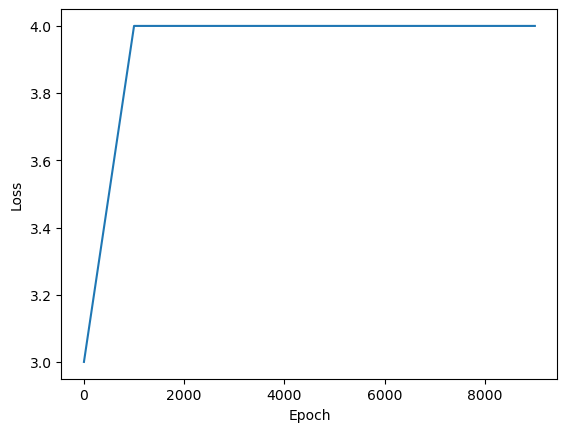

In [738]:
# XOR dataset:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# Initialize the perceptron with 2-dimensional inputs
perceptron = SingleLayerPerceptron(input_size=2)

# Train the perceptron
perceptron.train(X, y)

# Predictions
predictions = perceptron.predict(X)
print("Predicted label", predictions)
print("True label", y)

print(f"Accuracy: {100*np.sum(predictions == y) / len(y)}%")
plt.plot(perceptron.loss_history[:, 0], perceptron.loss_history[:, 1])
plt.xlabel('Epoch')
plt.ylabel('Loss')

Epoch 0, Total Loss: 1 Weights: (array([1.01584893, 1.80620426]), 0.06544532634003097)
Epoch 1000, Total Loss: 0 Weights: (array([2.01584893, 1.80620426]), -2.934554673659969)
Epoch 2000, Total Loss: 0 Weights: (array([2.01584893, 1.80620426]), -2.934554673659969)
Epoch 3000, Total Loss: 0 Weights: (array([2.01584893, 1.80620426]), -2.934554673659969)
Epoch 4000, Total Loss: 0 Weights: (array([2.01584893, 1.80620426]), -2.934554673659969)
Epoch 5000, Total Loss: 0 Weights: (array([2.01584893, 1.80620426]), -2.934554673659969)
Epoch 6000, Total Loss: 0 Weights: (array([2.01584893, 1.80620426]), -2.934554673659969)
Epoch 7000, Total Loss: 0 Weights: (array([2.01584893, 1.80620426]), -2.934554673659969)
Epoch 8000, Total Loss: 0 Weights: (array([2.01584893, 1.80620426]), -2.934554673659969)
Epoch 9000, Total Loss: 0 Weights: (array([2.01584893, 1.80620426]), -2.934554673659969)
Predicted label [0 0 0 1]
True label [0 0 0 1]
Accuracy: 100.0%


Text(0, 0.5, 'Loss')

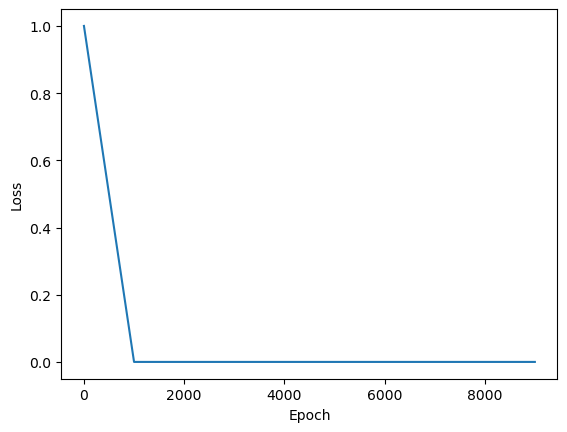

In [739]:
# AND dataset:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

# OR dataset:
# X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
# y = np.array([0, 1, 1, 1])

# Initialize the perceptron with 2-dimensional inputs
perceptron = SingleLayerPerceptron(input_size=2)

# Train the perceptron
perceptron.train(X, y)

# Predictions
predictions = perceptron.predict(X)
print("Predicted label", predictions)
print("True label", y)

print(f"Accuracy: {100*np.sum(predictions == y) / len(y)}%")
plt.plot(perceptron.loss_history[:, 0], perceptron.loss_history[:, 1])
plt.xlabel('Epoch')
plt.ylabel('Loss')

### Discussion: AND versus XOR

Look at the prediction and accuracy printed above. Now switch the commented dataset lines so that the same class is trained on **AND** instead of **XOR**.

Discuss:

1. Why can the same single-layer perceptron learn AND but not XOR?
2. What does the weight vector and bias represent in this example?
3. What does the final accuracy tell us about whether the problem is linearly separable?
4. Why is changing the dataset enough to change the outcome, even though the model class stays the same?

The key point is that a single-layer perceptron creates a **linear decision boundary**. AND is linearly separable, while XOR is not.

### From the perceptron to deep learning

This limitation gives us a natural reason to move toward neural networks. If one linear decision boundary is not enough for a problem such as XOR, we need a model that can represent nonlinear relationships.

A hidden layer with a nonlinear activation provides that extra flexibility. In the next section, we use this idea for **function approximation** rather than classification.

### A new question: can a neural network learn a function?

The perceptron example focused on classification. We now use a small MLP to approximate a continuous function and see why nonlinear activations matter.

# Part 5: Universal approximation — approximate $f(x)=\sin(x)$

We now move from classification to function approximation. Our target is $f(x)=\sin(x)$ on a finite interval.

A one-hidden-layer network can be written as:

$$h=\tanh(XW_1+b_1)$$

$$\hat{y}=hW_2+b_2$$

The nonlinear activation is important. Without it, two linear layers are still just one linear transformation.

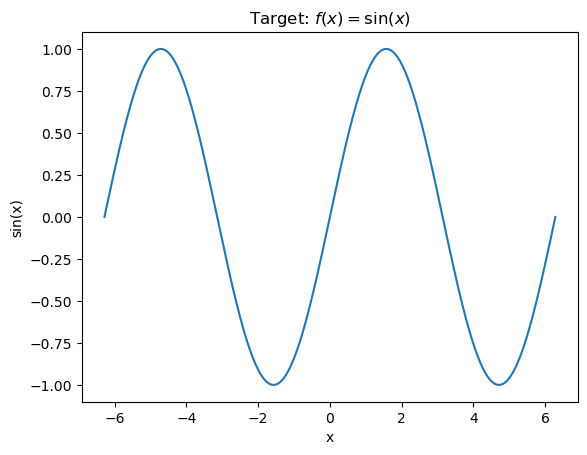

In [740]:
x_demo = np.linspace(-2 * np.pi, 2 * np.pi, 500).reshape(-1, 1)
y_demo = np.sin(x_demo)

plt.plot(x_demo, y_demo)
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.title(r"Target: $f(x)=\sin(x)$")
plt.show()

### Linear layers are not enough

Compare a network with two linear layers to one with a `Tanh` activation.

**Question:** Why does the linear network remain a straight line, even though it has two layers?

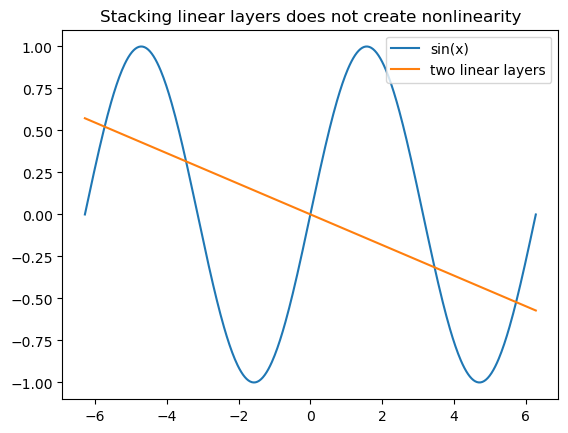

In [741]:
linear_model = nn.Sequential(
    nn.Linear(1, 20),
    nn.Linear(20, 1)
)

with torch.no_grad():
    linear_pred = linear_model(
        torch.tensor(x_demo, dtype=torch.float32)
    ).numpy()

plt.plot(x_demo, y_demo, label="sin(x)")
plt.plot(x_demo, linear_pred, label="two linear layers")
plt.legend()
plt.title("Stacking linear layers does not create nonlinearity")
plt.show()

### Fit $$\sin(x)$$ with a small MLP

Try a few hidden-layer widths.

The experiment shows the main intuition behind the universal approximation theorem: a nonlinear network with enough capacity can approximate a continuous function on a bounded domain.

It is **not** a proof of the theorem.

In [742]:
def make_sine_model(width):
    return nn.Sequential(
        nn.Linear(1, width),
        nn.Tanh(),
        nn.Linear(width, 1)
    )

x_train = torch.tensor(x_demo, dtype=torch.float32)
y_train = torch.tensor(y_demo, dtype=torch.float32)

def fit_sine_model(width, steps=1500, lr=0.01):
    model = make_sine_model(width)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        pred = model(x_train)
        loss = torch.mean((pred - y_train) ** 2)
        loss.backward()
        optimizer.step()

    return model, loss.item()

widths = [2, 5, 10, 20]
sine_results = {}

for width in widths:
    model, mse = fit_sine_model(width)
    sine_results[width] = (model, mse)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"width={width:2d} | parameters={n_params:3d} | MSE={mse:.7f}")

width= 2 | parameters=  7 | MSE=0.2917353
width= 5 | parameters= 16 | MSE=0.0320428
width=10 | parameters= 31 | MSE=0.0000711
width=20 | parameters= 61 | MSE=0.0000017


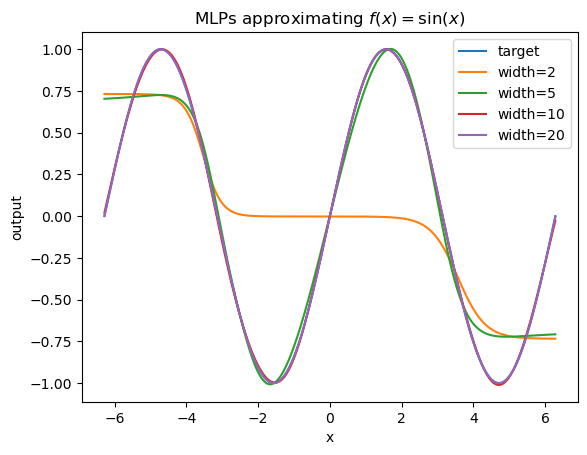

In [743]:
plt.plot(x_demo, y_demo, label="target")

for width, (model, _) in sine_results.items():
    with torch.no_grad():
        pred = model(x_train).numpy()
    plt.plot(x_demo, pred, label=f"width={width}")

plt.xlabel("x")
plt.ylabel("output")
plt.legend()
plt.title(r"MLPs approximating $f(x)=\sin(x)$")
plt.show()

### Discussion

What changes as the hidden layer gets wider?

1. Does more capacity always mean a better result?
2. What happens outside the interval used for training?
3. What would happen for $$f(x)=\sin(10x)$$?
4. What matters besides model size?

This is a good place to connect **representation, optimization, data, and generalization**.

# Part 6: Prompt engineering for coding and debugging

A good coding prompt gives the AI **enough information to reproduce the problem**. Use this simple structure:

1. **Goal:** What should the code do?
2. **Code:** Give the smallest useful example.
3. **Error:** Copy the exact traceback.
4. **Shapes:** Include important tensor shapes.
5. **Ask:** Request the smallest fix and a short explanation.

### Example

Instead of:

> “Fix my PyTorch code.”

Try:

> “This PyTorch model expects 3 input features, but I get a matrix multiplication shape error. Here is the smallest code that reproduces it: [code]. The input has shape `(16, 4)` and the layer expects 3 features. What is the smallest fix? Explain the shape mismatch in 2–3 sentences.”

**Important:** Run the suggested fix yourself. Do not assume the AI is correct.

In [744]:
# Debugging exercise
model = nn.Linear(3, 1)
X_bad = torch.randn(16, 4)
y_bad = torch.randn(16, 1)

try:
    pred = model(X_bad)
except Exception as e:
    print(type(e).__name__)
    print(e)

print("model weight:", tuple(model.weight.shape))
print("input:", tuple(X_bad.shape))
print("target:", tuple(y_bad.shape))

RuntimeError
mat1 and mat2 shapes cannot be multiplied (16x4 and 3x1)
model weight: (1, 3)
input: (16, 4)
target: (16, 1)


### Final challenge

The model **must stay a 3-feature model**.

Fix the data so that:

- the forward pass works,
- predictions have shape `(16, 1)`,
- the loss is a scalar.

Then verify your answer with assertions.

In [745]:
# TODO
# X_fixed = ...
# pred = model(X_fixed)
# loss = torch.mean((pred - y_bad) ** 2)

# assert X_fixed.shape == (16, 3)
# assert pred.shape == (16, 1)
# assert loss.ndim == 0
# print("Debugging task passed.")

# Takeaways

### Professional habits

- Predict tensor shapes before running code.
- Check results, not only whether code runs.
- Compare implementations against a reference when possible.
- Give an AI coding assistant the **goal, code, error, shapes, and constraints**.
- Always test an AI-generated fix.

# Part 7: Q&A